# Orbital Data Center: Levelized Cost of Compute (LCOC) Model

**Project:** Class analysis of whether passive radiative cooling can offset embodied launch energy and radiator mass costs for an orbital data center (ODC).

**Method:** First-principles sizing of PV array and radiator → mass and cost budget → LCOC via Nøland et al. (2024) Eq. 1.

**Notebook outline:**
1. Constants and locked assumptions
2. Scenario definitions (with explicit reasoning per variable)
3. Physical sizing (PV, radiator, mass)
4. LCOC calculation at year 0
5. Terrestrial DC baseline (apples-to-apples)
6. **Time projection 2026–2045 with learning rates**
7. Visualizations
8. Summary

## 1. Constants and locked assumptions

**Locked architecture:**
- 100 MW compute payload, training workload, LF = 1
- MEO at 15,000 km altitude (no eclipse, high radiation environment)
- 100% power conditioning efficiency
- 15-year spacecraft lifetime, 5-year IT refresh
- PV and radiator are one-time launches at year 0
- Two angled radiator arms at 45° from vertical, two-sided emission
- Triple-junction GaAs PV cells
- **OPEX = 0, no structural mass overhead**
- **Baseline compute efficiency: γ = 1.5 PFLOPS/kW (NVIDIA DGX H100 FP8)**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass, replace
from typing import Dict, List

# Physical constants
SIGMA = 5.67e-8
I_SUN = 1367
T_EARTH_EFF = 255
EARTH_ALBEDO = 0.30

# Architecture constants
Q_COMPUTE = 100e6
LIFETIME_YR = 15
REFRESH_INTERVAL = 5
HOURS_PER_YEAR = 8765.8
SECONDS_PER_YEAR = HOURS_PER_YEAR * 3600

# Compute efficiency ranges (PFLOPS/kW)
GAMMA_LOW  = 0.107   # NVIDIA Data Center GPU Max 1550 / older mix (Nøland Table 4)
GAMMA_NOM  = 1.5     # NVIDIA DGX H100 — baseline
GAMMA_HIGH = 6.0     # B200-class / future

## 2. Scenario definitions

Each scenario varies the technological and economic parameters together. Below is the parameter table with reasoning for each value.

### Optimistic — "Starship era, mature space tech"
Aspirational technology and aggressive cost reductions. Plausibly achievable by ~2030 if Starship hits target pricing and space-grade manufacturing scales.

| Variable | Value | Justification |
|---|---|---|
| Compute efficiency γ | **6.0 PFLOPS/kW** | Beyond DGX B200, next-gen accelerators |
| Launch cost | **$300/kg** | Starship target to LEO (extrapolated to MEO) |
| PV BOL efficiency | 34% | 4J / IMM space cells, near current SOA |
| PV derating | 0.90 | Best-case radiation/thermal/pointing |
| PV areal mass | 1.5 kg/m² | Modern flexible roll-out arrays |
| PV areal cost | $1,000/m² | Volume production, mature supply chain |
| Radiator areal mass | 3 kg/m² | Advanced composite face sheet + embedded LHPs |
| Radiator areal cost | $5,000/m² | Volume aerospace manufacturing |
| IT mass density | 15,000 kg/MW | Aggressive packing, lightweight chassis |
| IT cost | $5M/MW | Volume pricing of B200-class hardware |
| F_PV | 0.05 | Long boom, distributed array |
| T_PV | 60 °C | Well-designed back-side radiator |
| Radiator α_solar | 0.04 | SOA static RC coatings (Fan et al. Table 2) |
| Radiator ε_IR | 0.92 | SOA static RC coatings |
| Discount rate | 5% | Stable institutional financing |

### Nominal — "Mid-2020s realistic"
Current state-of-the-art with modest near-term improvements. Represents the most likely deployment scenario in the next 5–10 years.

| Variable | Value | Justification |
|---|---|---|
| Compute efficiency γ | **1.5 PFLOPS/kW** | NVIDIA DGX H100 FP8 (current production) |
| Launch cost | **$1,500/kg** | Falcon Heavy to LEO, mid-range for MEO |
| PV BOL efficiency | 32% | Current SOA space triple-junction (Azur 3G30, SpectroLab XTJ-Prime) |
| PV derating | 0.85 | Standard 15-year MEO degradation |
| PV areal mass | 3 kg/m² | Standard rigid panels with structure |
| PV areal cost | $2,500/m² | Current space-grade pricing |
| Radiator areal mass | 5 kg/m² | Conventional deployable radiator |
| Radiator areal cost | $10,000/m² | Mid-range aerospace component |
| IT mass density | 25,000 kg/MW | DGX-class with full chassis |
| IT cost | $10M/MW | Current H100 / B200 deployed pricing |
| F_PV | 0.15 | Modest boom, connected at body |
| T_PV | 80 °C | Typical operating temp without active cooling |
| Radiator α_solar | 0.05 | Standard space radiator coating |
| Radiator ε_IR | 0.90 | Standard space radiator coating |
| Discount rate | 8% | Mid-range commercial WACC |

### Pessimistic — "Costs don't fall, tech struggles"
If Starship doesn't reach target pricing, manufacturing remains low-volume, and radiation environment is worse than expected.

| Variable | Value | Justification |
|---|---|---|
| Compute efficiency γ | **0.107 PFLOPS/kW** | Older Intel/AMD mix (Nøland Table 4 lower end) |
| Launch cost | **$2,500/kg** | Falcon Heavy expendable / current commercial average |
| PV BOL efficiency | 30% | Conservative, accounting for radiation damage |
| PV derating | 0.75 | Aggressive radiation losses over 15 yr at MEO |
| PV areal mass | 5 kg/m² | Heavier rigid panels with shielding |
| PV areal cost | $5,000/m² | Limited supply, high cost |
| Radiator areal mass | 8 kg/m² | Conservative heritage design |
| Radiator areal cost | $20,000/m² | Low-volume aerospace pricing |
| IT mass density | 40,000 kg/MW | Heavy radiation-hardened racks |
| IT cost | $20M/MW | High pricing, no volume discount |
| F_PV | 0.25 | Short boom, large PV array nearby |
| T_PV | 100 °C | Hot PV operation, no thermal management |
| Radiator α_solar | 0.06 | Conservative coating performance |
| Radiator ε_IR | 0.88 | Coating degradation over life |
| Discount rate | 12% | High-risk financing premium |

In [2]:
@dataclass
class Scenario:
    name: str
    gamma_PFLOPS_per_kW: float
    # Radiator
    eps_IR: float; alpha_solar_rad: float
    F_earth: float; F_PV: float
    T_rad_C: float; T_chip_C: float; arm_angle_deg: float
    rad_areal_mass: float; rad_areal_cost: float
    # PV
    pv_eff_BOL: float; pv_derating: float
    T_PV_C: float; eps_PV_back: float
    pv_areal_mass: float; pv_areal_cost: float
    # Compute payload
    it_mass_density: float; it_cost_per_MW: float
    # Launch & data
    launch_cost_per_kg: float
    data_mass_per_drop: float; data_drops_per_year: float; data_fixed_cost: float
    # Financial
    discount_rate: float

OPTIMISTIC = Scenario(
    name='Optimistic',
    gamma_PFLOPS_per_kW=GAMMA_HIGH,
    eps_IR=0.92, alpha_solar_rad=0.04, F_earth=0.07, F_PV=0.05,
    T_rad_C=80, T_chip_C=85, arm_angle_deg=45,
    rad_areal_mass=3.0, rad_areal_cost=5000,
    pv_eff_BOL=0.34, pv_derating=0.90,
    T_PV_C=60, eps_PV_back=0.85,
    pv_areal_mass=1.5, pv_areal_cost=1000,
    it_mass_density=15000, it_cost_per_MW=5e6,
    launch_cost_per_kg=300,
    data_mass_per_drop=1000, data_drops_per_year=2, data_fixed_cost=0.5e6,
    discount_rate=0.05,
)
NOMINAL = Scenario(
    name='Nominal',
    gamma_PFLOPS_per_kW=GAMMA_NOM,
    eps_IR=0.90, alpha_solar_rad=0.05, F_earth=0.10, F_PV=0.15,
    T_rad_C=80, T_chip_C=85, arm_angle_deg=45,
    rad_areal_mass=5.0, rad_areal_cost=10000,
    pv_eff_BOL=0.32, pv_derating=0.85,
    T_PV_C=80, eps_PV_back=0.85,
    pv_areal_mass=3.0, pv_areal_cost=2500,
    it_mass_density=25000, it_cost_per_MW=10e6,
    launch_cost_per_kg=1500,
    data_mass_per_drop=1000, data_drops_per_year=2, data_fixed_cost=1.0e6,
    discount_rate=0.08,
)
PESSIMISTIC = Scenario(
    name='Pessimistic',
    gamma_PFLOPS_per_kW=GAMMA_LOW,
    eps_IR=0.88, alpha_solar_rad=0.06, F_earth=0.13, F_PV=0.25,
    T_rad_C=80, T_chip_C=85, arm_angle_deg=45,
    rad_areal_mass=8.0, rad_areal_cost=20000,
    pv_eff_BOL=0.30, pv_derating=0.75,
    T_PV_C=100, eps_PV_back=0.80,
    pv_areal_mass=5.0, pv_areal_cost=5000,
    it_mass_density=40000, it_cost_per_MW=20e6,
    launch_cost_per_kg=2500,
    data_mass_per_drop=1000, data_drops_per_year=2, data_fixed_cost=2.0e6,
    discount_rate=0.12,
)
SCENARIOS = [OPTIMISTIC, NOMINAL, PESSIMISTIC]

## 3. Physical sizing

In [3]:
def size_pv_array(s: Scenario) -> float:
    return Q_COMPUTE / (s.pv_eff_BOL * s.pv_derating * I_SUN)

def size_radiator(s: Scenario, verbose: bool = False) -> float:
    T_rad = s.T_rad_C + 273.15
    T_PV = s.T_PV_C + 273.15
    theta = np.radians(s.arm_angle_deg)
    P_emit = 2 * s.eps_IR * SIGMA * T_rad**4
    P_solar = s.alpha_solar_rad * I_SUN * np.cos(theta)
    P_albedo = s.alpha_solar_rad * EARTH_ALBEDO * I_SUN * s.F_earth
    P_earth_IR = s.eps_IR * SIGMA * T_EARTH_EFF**4 * s.F_earth
    P_PV = s.eps_IR * s.eps_PV_back * SIGMA * T_PV**4 * s.F_PV
    P_net = P_emit - P_solar - P_albedo - P_earth_IR - P_PV
    if P_net <= 0:
        raise ValueError(f'Net cooling non-positive ({P_net:.1f} W/m^2)')
    if verbose:
        print(f'  Emit:+{P_emit:.0f}  Solar:-{P_solar:.1f}  Albedo:-{P_albedo:.1f}  EarthIR:-{P_earth_IR:.1f}  PV-IR:-{P_PV:.1f}  Net:+{P_net:.0f} W/m^2')
    return Q_COMPUTE / P_net

def mass_budget(s: Scenario) -> Dict[str, float]:
    A_PV = size_pv_array(s)
    A_rad = size_radiator(s)
    return {
        'PV': A_PV * s.pv_areal_mass,
        'Radiator': A_rad * s.rad_areal_mass,
        'IT': (Q_COMPUTE / 1e6) * s.it_mass_density,
        'Total': A_PV*s.pv_areal_mass + A_rad*s.rad_areal_mass + (Q_COMPUTE/1e6)*s.it_mass_density,
        'A_PV': A_PV, 'A_rad': A_rad,
    }

print('Physical sizing:')
for s in SCENARIOS:
    A_PV = size_pv_array(s)
    print(f'\n{s.name}:')
    print(f'  PV array:  {A_PV:>9,.0f} m^2 ({A_PV/10000:.1f} ha)')
    A_rad = size_radiator(s, verbose=True)
    print(f'  Radiator:  {A_rad:>9,.0f} m^2')

print('\n\nMass budget [tonnes]:')
print(f'{"":12s}  {"Opt":>10s}  {"Nom":>10s}  {"Pes":>10s}')
for c in ['PV', 'Radiator', 'IT', 'Total']:
    row = f'{c:12s}  '
    for s in SCENARIOS:
        row += f'{mass_budget(s)[c]/1000:>8,.1f} t  '
    print(row)

Physical sizing:

Optimistic:
  PV array:    239,062 m^2 (23.9 ha)
  Emit:+1623  Solar:-38.7  Albedo:-1.1  EarthIR:-15.4  PV-IR:-27.3  Net:+1540 W/m^2
  Radiator:     64,929 m^2

Nominal:
  PV array:    268,944 m^2 (26.9 ha)
  Emit:+1587  Solar:-48.3  Albedo:-2.1  EarthIR:-21.6  PV-IR:-101.2  Net:+1414 W/m^2
  Radiator:     70,708 m^2

Pessimistic:
  PV array:    325,124 m^2 (32.5 ha)
  Emit:+1552  Solar:-58.0  Albedo:-3.2  EarthIR:-27.4  PV-IR:-193.5  Net:+1270 W/m^2
  Radiator:     78,737 m^2


Mass budget [tonnes]:
                     Opt         Nom         Pes
PV               358.6 t     806.8 t   1,625.6 t  
Radiator         194.8 t     353.5 t     629.9 t  
IT             1,500.0 t   2,500.0 t   4,000.0 t  
Total          2,053.4 t   3,660.4 t   6,255.5 t  


## 4. LCOC calculation

Following Nøland et al. (2024) Eq. 1. With $\alpha p k t = 0$ (no electricity cost) and $dc = 0$ (no OPEX):

$$ \text{LCOC} = \frac{\sum_i \text{cost}_i / (1+r)^i}{\sum_i \gamma k t / (1+r)^i} $$

In [4]:
def annual_eflop(s: Scenario, k_load: float = 1.0) -> float:
    """Annual compute output [EFLOP/year]. gamma is PFLOPS/kW = PFLOP/s/kW."""
    return (Q_COMPUTE / 1000) * s.gamma_PFLOPS_per_kW / 1000 * SECONDS_PER_YEAR * k_load

def build_cash_flows(s: Scenario) -> Dict[str, np.ndarray]:
    mb = mass_budget(s)
    cost_PV = mb['A_PV'] * s.pv_areal_cost
    cost_rad = mb['A_rad'] * s.rad_areal_cost
    cost_IT = (Q_COMPUTE / 1e6) * s.it_cost_per_MW
    launch_year0 = mb['Total'] * s.launch_cost_per_kg
    launch_refresh = mb['IT'] * s.launch_cost_per_kg
    hardware = np.zeros(LIFETIME_YR)
    launch = np.zeros(LIFETIME_YR)
    data = np.zeros(LIFETIME_YR)
    hardware[0] = cost_PV + cost_rad + cost_IT
    launch[0] = launch_year0
    for ry in [5, 10]:
        hardware[ry] += cost_IT
        launch[ry] += launch_refresh
    cost_per_drop = s.data_fixed_cost + s.data_mass_per_drop * s.launch_cost_per_kg
    data[:] = cost_per_drop * s.data_drops_per_year
    return {'hardware': hardware, 'launch': launch, 'data': data,
            'total': hardware + launch + data}

def calculate_lcoc(s: Scenario) -> Dict[str, float]:
    cf = build_cash_flows(s)
    years = np.arange(LIFETIME_YR)
    annual_compute = np.full(LIFETIME_YR, annual_eflop(s))
    discount = 1.0 / (1 + s.discount_rate)**years
    npv_cost = (cf['total'] * discount).sum()
    npv_compute = (annual_compute * discount).sum()
    lcoc = npv_cost / npv_compute
    breakdown = {
        'Hardware': (cf['hardware'] * discount).sum() / npv_compute,
        'Launch':   (cf['launch']   * discount).sum() / npv_compute,
        'Data':     (cf['data']     * discount).sum() / npv_compute,
    }
    return {'lcoc': lcoc, 'breakdown': breakdown, 'npv_cost': npv_cost}

results = {}
for s in SCENARIOS:
    results[s.name] = calculate_lcoc(s)
    r = results[s.name]
    print(f'\n{s.name}: γ={s.gamma_PFLOPS_per_kW} PFLOPS/kW → LCOC = ${r["lcoc"]:.4f}/EFLOP (NPV ${r["npv_cost"]/1e9:.2f}B)')
    for cat, val in r['breakdown'].items():
        print(f'  {cat:10s} ${val:.4f}/EFLOP')


Optimistic: γ=6.0 PFLOPS/kW → LCOC = $0.0147/EFLOP (NPV $3.02B)
  Hardware   $0.0085/EFLOP
  Launch     $0.0060/EFLOP
  Data       $0.0001/EFLOP

Nominal: γ=1.5 PFLOPS/kW → LCOC = $0.3051/EFLOP (NPV $13.35B)
  Hardware   $0.0805/EFLOP
  Launch     $0.2235/EFLOP
  Data       $0.0011/EFLOP

Pessimistic: γ=0.107 PFLOPS/kW → LCOC = $12.2609/EFLOP (NPV $31.58B)
  Hardware   $2.7096/EFLOP
  Launch     $9.5246/EFLOP
  Data       $0.0267/EFLOP


## 5. Terrestrial DC baseline (Nøland et al. methodology)

Using their Table 5 baseline parameters: c=$10,000/kW, d=10%, α=1.12, p=$150/MWh, r=10%, n=15, k=1.

Computed at the **same γ as each ODC scenario** for apples-to-apples comparison.

In [5]:
def terrestrial_lcoc(gamma_PFLOPS_per_kW: float,
                     c_per_kW: float = 10000, d_frac: float = 0.10,
                     alpha_PUE: float = 1.12, p_per_MWh: float = 150,
                     r_wacc: float = 0.10, n_years: int = 15,
                     k_load: float = 1.0) -> float:
    """Nøland et al. 2024 Eq. 1 — returns terrestrial LCOC in $/EFLOP."""
    annual_elec = alpha_PUE * (p_per_MWh / 1000) * k_load * HOURS_PER_YEAR
    annual_opex = d_frac * c_per_kW
    annual_compute = gamma_PFLOPS_per_kW * k_load * SECONDS_PER_YEAR
    df = np.array([1/(1+r_wacc)**i for i in range(n_years)])
    npv_costs = c_per_kW + ((annual_elec + annual_opex) * df).sum()
    npv_compute = (annual_compute * df).sum()
    return (npv_costs / npv_compute) * 1000  # $/PFLOP -> $/EFLOP

# Sanity check vs published $1.16
verify = terrestrial_lcoc(0.1)
print(f'Verification @ γ=0.1: ${verify:.3f}/EFLOP (paper says $1.16) ✓')

terr = {}
for s in SCENARIOS:
    terr[s.name] = terrestrial_lcoc(s.gamma_PFLOPS_per_kW)
    print(f'Terrestrial @ γ={s.gamma_PFLOPS_per_kW:>5.3f} (matches {s.name}): ${terr[s.name]:.4f}/EFLOP')

Verification @ γ=0.1: $1.162/EFLOP (paper says $1.16) ✓
Terrestrial @ γ=6.000 (matches Optimistic): $0.0194/EFLOP
Terrestrial @ γ=1.500 (matches Nominal): $0.0775/EFLOP
Terrestrial @ γ=0.107 (matches Pessimistic): $1.0863/EFLOP


## 6. Time projection 2026–2045 with learning rates

We apply annual % decline rates to costs and annual % growth to efficiencies. These are time-based (not Wright's-Law cumulative-production-based), which is a simplification but transparent and defensible for a class project.

### Learning rate assumptions

| Parameter | Annual change | Justification |
|---|---|---|
| Launch cost ($/kg) | **−12%/yr** | Historical SpaceX trajectory ~15%/yr; conservative going forward |
| PV $/m² | **−6%/yr** | Solar PV historical 10%/yr; space-grade is slower |
| Radiator $/m² | **−3%/yr** | Mature aerospace tech, slow gains |
| IT $/MW | **−8%/yr** | Cost-per-FLOP improvement, slower than performance |
| Compute efficiency γ | **+15%/yr** | Historical AI hardware ~25%/yr but slowing |
| PV efficiency | **+0.3 pp/yr abs** | Theoretical limit caps absolute gains |
| Terrestrial DC CAPEX ($/kW) | **−2%/yr** | Mature tech, slow gains |
| Electricity price ($/MWh) | **0%/yr real** | Real-terms flat |

**Key insight:** γ improvement applies equally to ODC and TDC, so it shifts both lines down in parallel. The *gap* is driven by launch cost decline (helps ODC) vs. terrestrial cost decline (helps TDC).

In [6]:
@dataclass
class LearningRates:
    launch: float = 0.12          # 12% annual decline
    pv_cost: float = 0.06
    rad_cost: float = 0.03
    it_cost: float = 0.08
    gamma_growth: float = 0.15    # 15% annual growth
    pv_eff_pp: float = 0.003      # +0.3 percentage points per year (additive)
    terr_capex: float = 0.02      # 2% annual decline in TDC CAPEX
    elec_price: float = 0.0       # real-terms flat

LR = LearningRates()

def evolve_scenario(s_base: Scenario, year_offset: int, lr: LearningRates) -> Scenario:
    """Return a Scenario representing s_base evolved year_offset years into the future."""
    return replace(s_base,
        gamma_PFLOPS_per_kW = s_base.gamma_PFLOPS_per_kW * (1 + lr.gamma_growth)**year_offset,
        launch_cost_per_kg  = s_base.launch_cost_per_kg  * (1 - lr.launch)**year_offset,
        pv_areal_cost       = s_base.pv_areal_cost       * (1 - lr.pv_cost)**year_offset,
        rad_areal_cost      = s_base.rad_areal_cost      * (1 - lr.rad_cost)**year_offset,
        it_cost_per_MW      = s_base.it_cost_per_MW      * (1 - lr.it_cost)**year_offset,
        pv_eff_BOL          = min(0.40, s_base.pv_eff_BOL + lr.pv_eff_pp * year_offset),
    )

def terrestrial_evolved(gamma_baseline: float, year_offset: int, lr: LearningRates) -> float:
    gamma_t = gamma_baseline * (1 + lr.gamma_growth)**year_offset
    capex_t = 10000 * (1 - lr.terr_capex)**year_offset
    return terrestrial_lcoc(gamma_t, c_per_kW=capex_t)

# Project each scenario forward
START_YEAR = 2026
END_YEAR = 2045
years_calendar = np.arange(START_YEAR, END_YEAR + 1)
year_offsets = years_calendar - START_YEAR

lcoc_odc_over_time = {s.name: [] for s in SCENARIOS}
lcoc_tdc_over_time = {s.name: [] for s in SCENARIOS}

for s in SCENARIOS:
    for yo in year_offsets:
        evolved = evolve_scenario(s, yo, LR)
        lcoc_odc_over_time[s.name].append(calculate_lcoc(evolved)['lcoc'])
        lcoc_tdc_over_time[s.name].append(terrestrial_evolved(s.gamma_PFLOPS_per_kW, yo, LR))

for s in SCENARIOS:
    lcoc_odc_over_time[s.name] = np.array(lcoc_odc_over_time[s.name])
    lcoc_tdc_over_time[s.name] = np.array(lcoc_tdc_over_time[s.name])

# Print year-0 and year-2045 values
print(f'{"Scenario":12s}  {"Year":>6s}  {"ODC":>12s}  {"TDC":>12s}  {"ODC/TDC":>8s}')
for s in SCENARIOS:
    for label, idx in [('2026', 0), ('2035', 9), ('2045', 19)]:
        odc = lcoc_odc_over_time[s.name][idx]
        tdc = lcoc_tdc_over_time[s.name][idx]
        print(f'{s.name:12s}  {label:>6s}  ${odc:>10.4f}  ${tdc:>10.4f}  {odc/tdc:>7.2f}x')

Scenario        Year           ODC           TDC   ODC/TDC
Optimistic      2026  $    0.0147  $    0.0194     0.76x
Optimistic      2035  $    0.0019  $    0.0050     0.37x
Optimistic      2045  $    0.0002  $    0.0011     0.19x
Nominal         2026  $    0.3051  $    0.0775     3.94x
Nominal         2035  $    0.0325  $    0.0198     1.64x
Nominal         2045  $    0.0030  $    0.0044     0.68x
Pessimistic     2026  $   12.2609  $    1.0863    11.29x
Pessimistic     2035  $    1.2732  $    0.2781     4.58x
Pessimistic     2045  $    0.1151  $    0.0618     1.86x


## 7. Visualizations

### 7a. LCOC by scenario (year 0 / 2026 baseline)

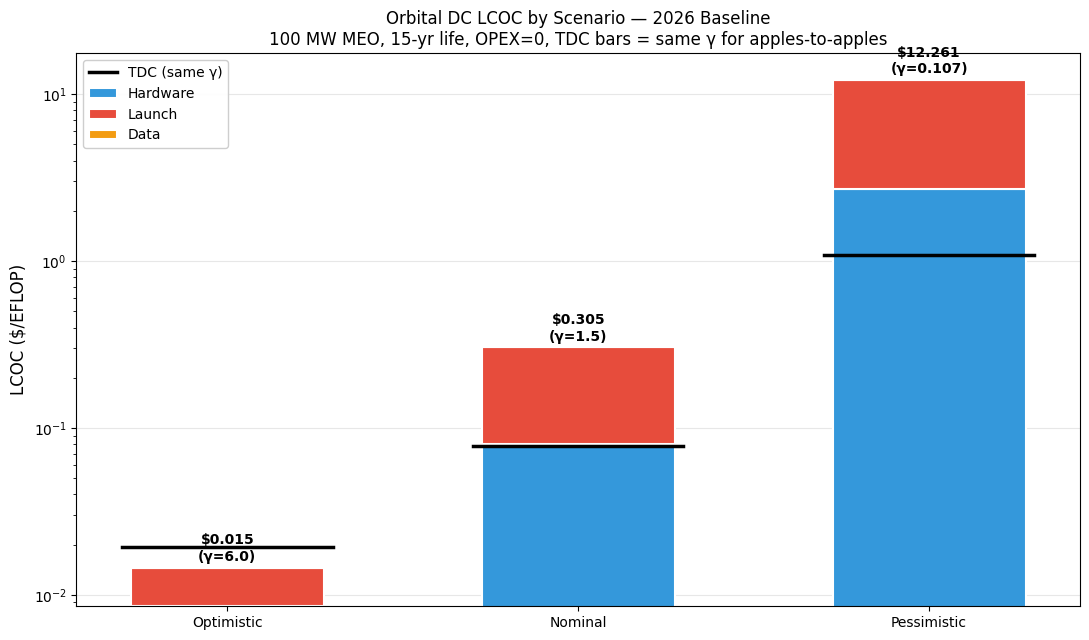

In [9]:
fig, ax = plt.subplots(figsize=(11, 6.5))
scenario_names = [s.name for s in SCENARIOS]
categories = ['Hardware', 'Launch', 'Data']
colors = {'Hardware': '#3498db', 'Launch': '#e74c3c', 'Data': '#f39c12'}

bottoms = np.zeros(len(scenario_names))
for cat in categories:
    values = [results[name]['breakdown'][cat] for name in scenario_names]
    ax.bar(scenario_names, values, bottom=bottoms, label=cat,
           color=colors[cat], edgecolor='white', linewidth=1.5, width=0.55)
    bottoms += np.array(values)

for i, name in enumerate(scenario_names):
    total = results[name]['lcoc']
    s = SCENARIOS[i]
    ax.text(i, total * 1.05, f'${total:.3f}\n(γ={s.gamma_PFLOPS_per_kW})',
            ha='center', va='bottom', fontweight='bold', fontsize=10)

# Plot matched terrestrial baseline for each scenario
for i, s in enumerate(SCENARIOS):
    ax.plot([i - 0.3, i + 0.3], [terr[s.name], terr[s.name]],
            color='black', linewidth=2.5, label='TDC (same γ)' if i == 0 else None)

ax.set_ylabel('LCOC ($/EFLOP)', fontsize=12)
ax.set_title('Orbital DC LCOC by Scenario — 2026 Baseline\n100 MW MEO, 15-yr life, OPEX=0, TDC bars = same γ for apples-to-apples',
             fontsize=12)
ax.legend(loc='upper left', framealpha=0.95, fontsize=10)
ax.grid(axis='y', alpha=0.3); ax.set_axisbelow(True)
ax.set_yscale('log')
plt.tight_layout()
# plt.savefig('/home/claude/lcoc_scenarios.png', dpi=150, bbox_inches='tight')
plt.show()

### 7b. LCOC vs time — projected technology improvement

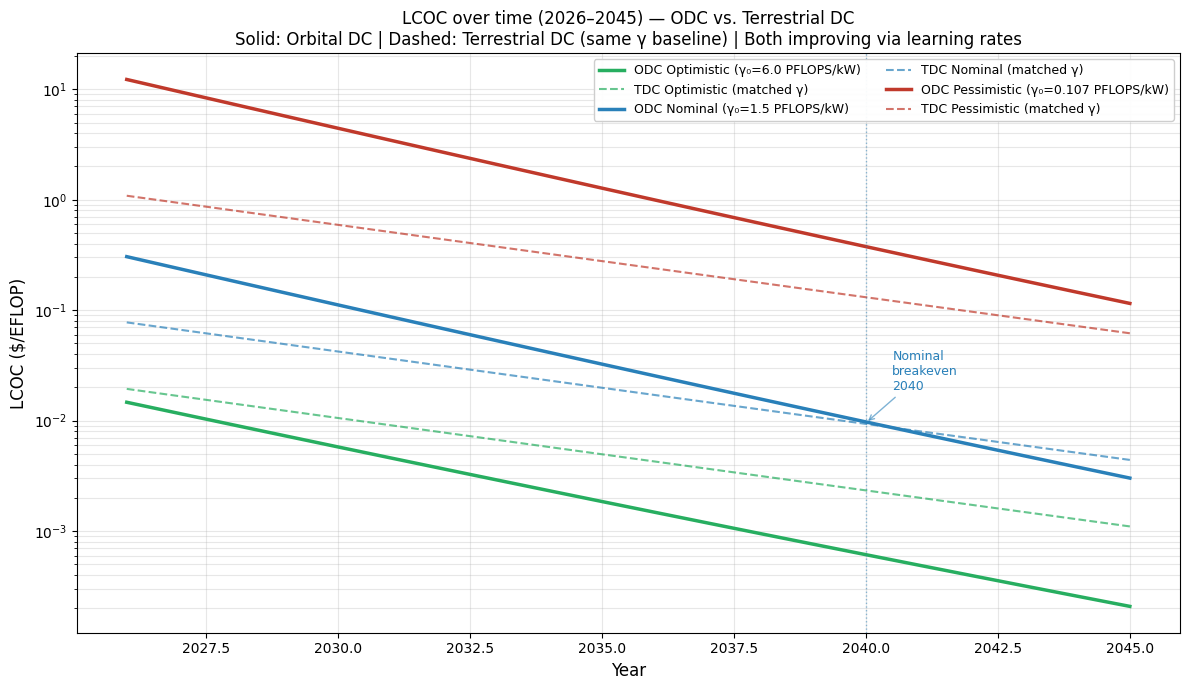

In [10]:
fig, ax = plt.subplots(figsize=(12, 7))
scenario_colors = {'Optimistic': '#27ae60', 'Nominal': '#2980b9', 'Pessimistic': '#c0392b'}

for s in SCENARIOS:
    c = scenario_colors[s.name]
    ax.plot(years_calendar, lcoc_odc_over_time[s.name], color=c, linewidth=2.5,
            label=f'ODC {s.name} (γ₀={s.gamma_PFLOPS_per_kW} PFLOPS/kW)')
    ax.plot(years_calendar, lcoc_tdc_over_time[s.name], color=c, linewidth=1.5,
            linestyle='--', alpha=0.7, label=f'TDC {s.name} (matched γ)')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('LCOC ($/EFLOP)', fontsize=12)
ax.set_yscale('log')
ax.set_title('LCOC over time (2026–2045) — ODC vs. Terrestrial DC\nSolid: Orbital DC | Dashed: Terrestrial DC (same γ baseline) | Both improving via learning rates',
             fontsize=12)
ax.legend(loc='upper right', framealpha=0.95, fontsize=9, ncol=2)
ax.grid(True, which='both', alpha=0.3); ax.set_axisbelow(True)

# Annotate crossover years where ODC = TDC, if any
for s in SCENARIOS:
    odc = lcoc_odc_over_time[s.name]
    tdc = lcoc_tdc_over_time[s.name]
    diff = odc - tdc
    sign_changes = np.where(np.diff(np.sign(diff)))[0]
    if len(sign_changes) > 0:
        cross_idx = sign_changes[0]
        cross_year = years_calendar[cross_idx]
        cross_lcoc = (odc[cross_idx] + tdc[cross_idx]) / 2
        ax.axvline(cross_year, color=scenario_colors[s.name], linestyle=':', alpha=0.5, linewidth=1)
        ax.annotate(f'{s.name}\nbreakeven\n{cross_year}',
                    xy=(cross_year, cross_lcoc),
                    xytext=(cross_year + 0.5, cross_lcoc * 2),
                    fontsize=9, color=scenario_colors[s.name],
                    arrowprops=dict(arrowstyle='->', color=scenario_colors[s.name], alpha=0.6))

plt.tight_layout()
# plt.savefig('/home/claude/lcoc_vs_time.png', dpi=150, bbox_inches='tight')
plt.show()

### 7c. ODC/TDC ratio over time — does the gap close?

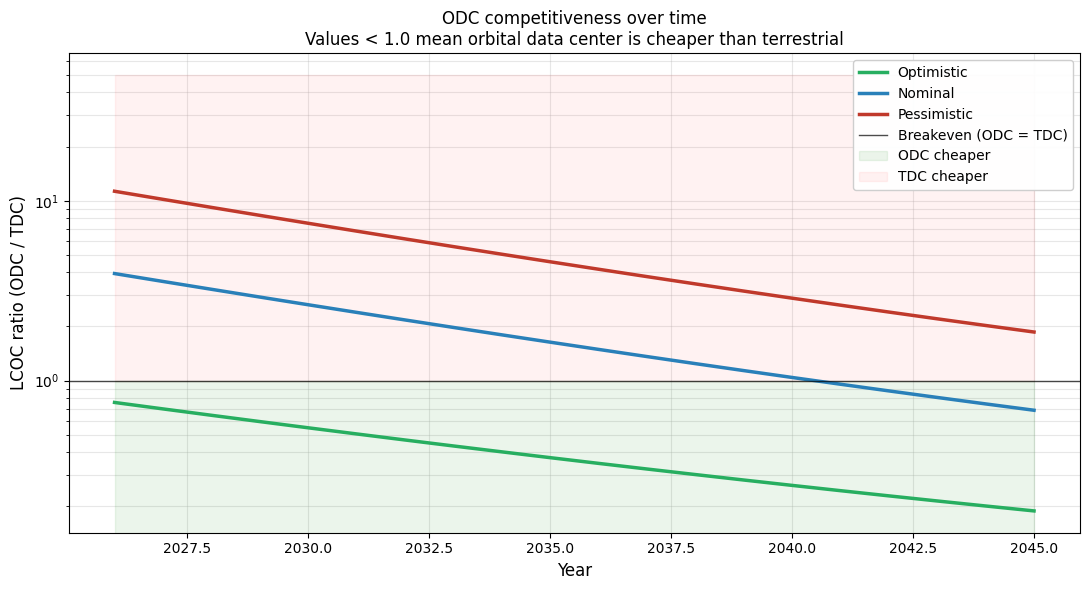

In [11]:
fig, ax = plt.subplots(figsize=(11, 6))
for s in SCENARIOS:
    ratio = lcoc_odc_over_time[s.name] / lcoc_tdc_over_time[s.name]
    ax.plot(years_calendar, ratio, color=scenario_colors[s.name], linewidth=2.5, label=s.name)

ax.axhline(1.0, color='black', linestyle='-', linewidth=1, alpha=0.7,
           label='Breakeven (ODC = TDC)')
ax.fill_between(years_calendar, 0, 1, alpha=0.08, color='green', label='ODC cheaper')
ax.fill_between(years_calendar, 1, 50, alpha=0.05, color='red', label='TDC cheaper')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('LCOC ratio (ODC / TDC)', fontsize=12)
ax.set_yscale('log')
ax.set_title('ODC competitiveness over time\nValues < 1.0 mean orbital data center is cheaper than terrestrial', fontsize=12)
ax.legend(loc='upper right', framealpha=0.95, fontsize=10)
ax.grid(True, which='both', alpha=0.3); ax.set_axisbelow(True)
plt.tight_layout()
# plt.savefig('/home/claude/lcoc_ratio.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Summary

In [12]:
print('=' * 78)
print('SUMMARY: Orbital vs Terrestrial DC LCOC (2026–2045 projection)')
print('=' * 78)
print()
for s in SCENARIOS:
    print(f'--- {s.name} (γ₀ = {s.gamma_PFLOPS_per_kW} PFLOPS/kW) ---')
    for label, idx in [('2026', 0), ('2035', 9), ('2045', 19)]:
        odc = lcoc_odc_over_time[s.name][idx]
        tdc = lcoc_tdc_over_time[s.name][idx]
        verdict = 'ODC wins' if odc < tdc else 'TDC wins'
        print(f'  {label}:  ODC ${odc:>8.4f}/EFLOP  |  TDC ${tdc:>8.4f}/EFLOP  |  ratio {odc/tdc:>5.2f}x  ({verdict})')
    print()

SUMMARY: Orbital vs Terrestrial DC LCOC (2026–2045 projection)

--- Optimistic (γ₀ = 6.0 PFLOPS/kW) ---
  2026:  ODC $  0.0147/EFLOP  |  TDC $  0.0194/EFLOP  |  ratio  0.76x  (ODC wins)
  2035:  ODC $  0.0019/EFLOP  |  TDC $  0.0050/EFLOP  |  ratio  0.37x  (ODC wins)
  2045:  ODC $  0.0002/EFLOP  |  TDC $  0.0011/EFLOP  |  ratio  0.19x  (ODC wins)

--- Nominal (γ₀ = 1.5 PFLOPS/kW) ---
  2026:  ODC $  0.3051/EFLOP  |  TDC $  0.0775/EFLOP  |  ratio  3.94x  (TDC wins)
  2035:  ODC $  0.0325/EFLOP  |  TDC $  0.0198/EFLOP  |  ratio  1.64x  (TDC wins)
  2045:  ODC $  0.0030/EFLOP  |  TDC $  0.0044/EFLOP  |  ratio  0.68x  (ODC wins)

--- Pessimistic (γ₀ = 0.107 PFLOPS/kW) ---
  2026:  ODC $ 12.2609/EFLOP  |  TDC $  1.0863/EFLOP  |  ratio 11.29x  (TDC wins)
  2035:  ODC $  1.2732/EFLOP  |  TDC $  0.2781/EFLOP  |  ratio  4.58x  (TDC wins)
  2045:  ODC $  0.1151/EFLOP  |  TDC $  0.0618/EFLOP  |  ratio  1.86x  (TDC wins)

